# Test d'un AFC sur un corpus de textes en français avec auteur naturaliste et non naturaliste

In [31]:
import os   
import pandas as pd 
import spacy
import matplotlib.pyplot as plt
from fanalysis.ca import CA
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial import distance_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

## Chargement des données (dans le fichier data)

In [6]:
dossier = "DATA"
documents = []
titres = []

# On boucle sur tous les fichiers texte du dossier
for fichier in os.listdir(dossier):
    if fichier.endswith(".txt"):
        titres.append(fichier.replace(".txt", ""))
        # Lecture avec encodage utf-8 pour le français
        with open(os.path.join(dossier, fichier), 'r', encoding='utf-8') as f:
            documents.append(f.read())

print(f"{len(documents)} textes chargés avec succès.")

16 textes chargés avec succès.


In [12]:
nlp = spacy.load("fr_core_news_lg")
mots_vides_fr = list(nlp.Defaults.stop_words)

# Début ACF (analyse en Composantes Factorielles)

### Préparation de la matrice de documents

In [13]:
vectorizer = CountVectorizer(stop_words=mots_vides_fr, min_df=4, max_df=0.8)
X = vectorizer.fit_transform(documents)

/Users/morganr/AFC-Naturalisme/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


In [14]:
valeurs = X.toarray()
etiquettes_textes = titres
etiquettes_mots = vectorizer.get_feature_names_out()

### Paramètres de l'AFC

In [15]:
afc = CA(row_labels=etiquettes_textes, col_labels=etiquettes_mots)
afc.fit(valeurs)

,row_labels,"['1887_Bloy_Desespere_C', '1889_ Descaves_SousOffs_C', ...]"
,col_labels,"array(['10', ... dtype=object)"
,n_components,None
,stats,True
Name,Type,Value
c_,"ndarray[int64](1, 13474)","[[15,11,13,...,13,39,39]]"
col_contrib_,"ndarray[float64](13474, 15)","[[0. ,0. ,0.02,...,0. ,0.01,0. ], [0. ,0. ,0.03,...,0. ,0.02,0. ], [0. ,0. ,0.01,...,0.01,0. ,0. ], ..., [0.01,0.01,0. ,...,0. ,0.01,0. ], [0. ,0. ,0.01,...,0. ,0.04,0. ], [0. ,0. ,0.01,...,0.02,0.02,0.11]]"
col_coord_,"ndarray[float64](13474, 15)","[[ 0.15,-0.08, 0.7 ,...,-0.11, 0.47, 0.22], [ 0.32, 0.13, 1.07,...,-0.29, 0.7 , 0.23], [ 0.12, 0.22, 0.52,...,-0.52,-0.03,-0.28], ..., [-0.58, 0.44,-0.25,..., 0.19,-0.31,-0.14], [ 0.01, 0.16,-0.29,...,-0.1 ,-0.48, 0.06], [ 0.16,-0.13,-0.38,..., 0.35,-0.32,-0.78]]"
col_cos2_,"ndarray[float64](13474, 15)","[[0.01,0. ,0.26,...,0.01,0.11,0.03], [0.03,0. ,0.3 ,...,0.02,0.13,0.01], [0.01,0.02,0.14,...,0.14,0. ,0.04], ..., [0.17,0.1 ,0.03,...,0.02,0.05,0.01], [0. ,0.02,0.08,...,0.01,0.22,0. ], [0.01,0.01,0.05,...,0.04,0.03,0.19]]"
col_labels_,"ndarray[object](13474,)","['10','11','12',...,'œuf','œufs','œuvres']"
col_labels_short_,"ndarray[object](13474,)","['10','11','12',...,'œuf','œufs','œuvres']"


### Visualisation des contributions des mots

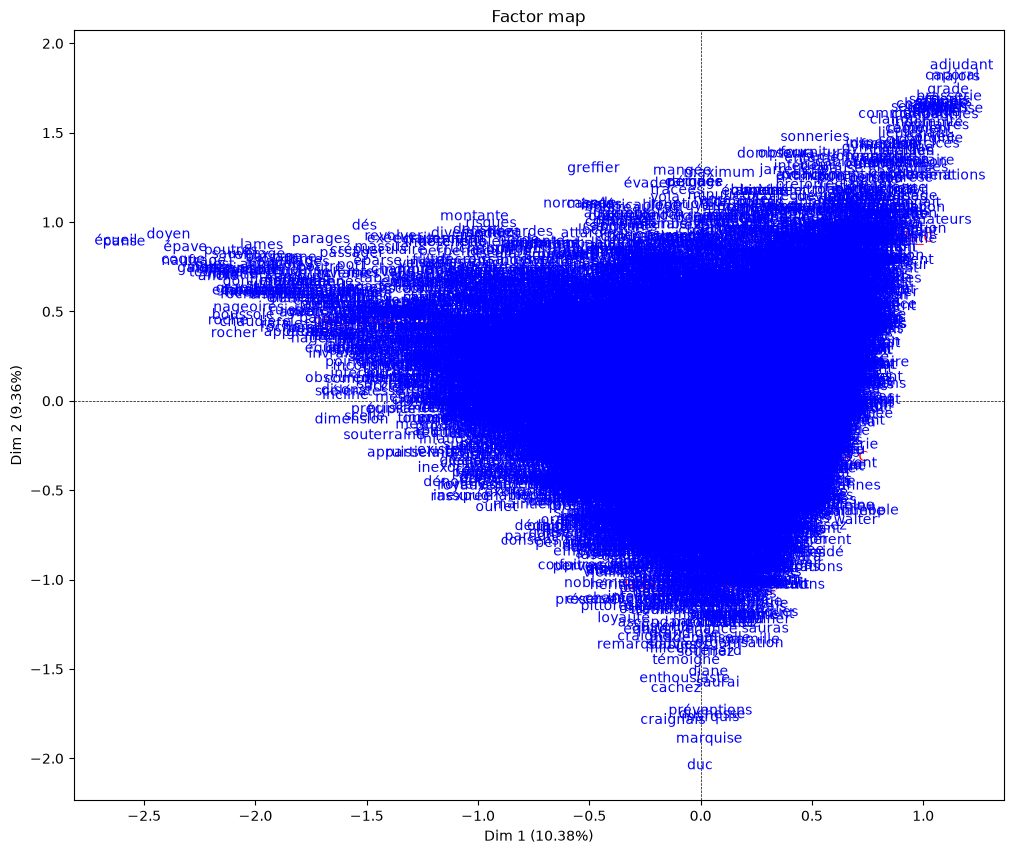

In [18]:
afc.mapping(num_x_axis=1, num_y_axis=2, figsize=(12, 10))
plt.show()

In [ ]:
# 1. Extraction des contributions (en pourcentages)
contributions_mots = afc.col_contrib_

# 2. Création du DataFrame global
df_contrib = pd.DataFrame({
    'Mot': etiquettes_mots,
    'Contrib_Axe1': contributions_mots[:, 0], # Index 0 = Axe 1
    'Contrib_Axe2': contributions_mots[:, 1]  # Index 1 = Axe 2
})

# 3. Extraction du Top 15 pour l'Axe 1
top_axe1 = df_contrib.sort_values(by='Contrib_Axe1', ascending=False).head(15)

# 4. Extraction du Top 15 pour l'Axe 2
top_axe2 = df_contrib.sort_values(by='Contrib_Axe2', ascending=False).head(15)

# Affichage des résultats
print("--- TOP 15 : MOTS STRUCTURANT L'AXE 1 ---")
print(top_axe1[['Mot', 'Contrib_Axe1']])

print("\n--- TOP 15 : MOTS STRUCTURANT L'AXE 2 ---")
print(top_axe2[['Mot', 'Contrib_Axe2']])

--- TOP 15 : MOTS STRUCTURANT L'AXE 1 ---
             Mot  Contrib_Axe1
8505       panse      1.895931
13061     écueil      1.758623
10571     rocher      1.346371
7338     machine      1.245199
8048      navire      1.156193
10572    rochers      0.805318
10570      roche      0.762445
7525       marée      0.705249
11266      sieur      0.695312
8280   officiers      0.643100
13221      épave      0.640023
5235        flot      0.612937
7060       lames      0.604318
1330      barque      0.602655
8262       océan      0.594771

--- TOP 15 : MOTS STRUCTURANT L'AXE 2 ---
                Mot  Contrib_Axe2
7508        marquis      3.054455
3711            duc      2.941887
7509       marquise      1.928010
8280      officiers      1.678140
11221       sergent      1.458031
5962      généreuse      1.250222
7378          major      1.092565
295        adjudant      1.026358
2401          coeur      0.949494
1964        caserne      0.892057
11349        soldat      0.853340
7341   made

In [20]:
coords_textes = afc.row_coord_[:, :2]

# On met ça au propre dans un DataFrame
df_textes = pd.DataFrame({
    'Texte': etiquettes_textes,
    'Coord_Axe1': coords_textes[:, 0],
    'Coord_Axe2': coords_textes[:, 1]
}).set_index('Texte')

print("--- POSITION DES TEXTES SUR LES AXES 1 ET 2 ---")
print(df_textes.head())

--- POSITION DES TEXTES SUR LES AXES 1 ET 2 ---
                           Coord_Axe1  Coord_Axe2
Texte                                            
1887_Bloy_Desespere_C       -0.175403   -0.431258
1889_ Descaves_SousOffs_C    0.594731    0.910924
1886_Husymans_rade_C        -0.114695    0.346406
1885_Maupassant_Ami_C        0.349482   -0.313960
1884_Alis_Soleil_C           0.068182   -0.101625


In [30]:
print("Voici les textes actuellement chargés dans le corpus :")
for i, titre in enumerate(titres):
    print(f"{i} : {titre}")

Voici les textes actuellement chargés dans le corpus :
0 : 1887_Bloy_Desespere_C
1 : 1889_ Descaves_SousOffs_C
2 : 1886_Husymans_rade_C
3 : 1885_Maupassant_Ami_C
4 : 1884_Alis_Soleil_C
5 : 1860_Goncourt_Demailly_I
6 : 1883_Bonnetain_Charlot_C
7 : 1886_Valles_Insurge_C
8 : 1869_Flaubert_education_I
9 : 1886_Rosny_Horn_C
10 : 1866_Hugo_travailleurs_I
11 : 1883_Cherbuliez_Choquard_C
12 : 1857_Flaubert_Bovary_I
13 : 1864_Sand_Villemer_I
14 : 1865_Gautier_Jenny_I
15 : 1885_Adam_molle_C


In [29]:
matrice_dist = distance_matrix(coords_textes, coords_textes)

# On transforme ça en tableau lisible avec le nom des textes en lignes et colonnes
df_distances = pd.DataFrame(
    matrice_dist, 
    index=etiquettes_textes, 
    columns=etiquettes_textes
)

# Exemple : Trouvons les 3 textes les plus proches du premier texte de ta liste
# (On exclut le premier résultat car la distance d'un texte avec lui-même est toujours de 0)
texte_cible = etiquettes_textes[6] 

voisins = df_distances[texte_cible].sort_values()[1:6]

print(f"\n--- TEXTES LES PLUS PROCHES DE '{texte_cible}' ---")
print(voisins)


--- TEXTES LES PLUS PROCHES DE '1883_Bonnetain_Charlot_C' ---
1886_Valles_Insurge_C        0.026609
1885_Adam_molle_C            0.185787
1886_Husymans_rade_C         0.329742
1857_Flaubert_Bovary_I       0.348032
1869_Flaubert_education_I    0.360979
Name: 1883_Bonnetain_Charlot_C, dtype: float64


/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_45140/3646505815.py:1: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  matrice_dist = distance_matrix(coords_textes, coords_textes)
/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_45140/3646505815.py:1: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  matrice_dist = distance_matrix(coords_textes, coords_textes)
/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_45140/3646505815.py:1: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  matrice_dist = distance_matrix(coords_textes, coords_textes)
